In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import scipy.stats
import torch
from torch import tensor, Tensor

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import block_formats.quantisation as Q
import plot_utils

plot_utils.configure()

LM_UNDERLAY_ARGS = dict(zorder=0, lw=3, ms=6, alpha=.5, marker="x")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def sample(n: int, dist: str, scale: float = 1.0, *, seed: int, **args: float) -> Tensor:
    cls = getattr(torch.distributions, dist)
    cls_args = dict(loc=tensor(0.0, dtype=torch.float32, device=DEVICE), scale=tensor(scale, dtype=torch.float32, device=DEVICE))
    if dist == "StudentT":
        cls_args["df"] = tensor(args["dof"], dtype=torch.float32, device=DEVICE)
    torch.manual_seed(int(np.random.SeedSequence(seed).generate_state(1)[0]))
    return cls(**cls_args).sample((n,))

Recommend (Ubuntu):
  sudo apt-get install cm-super dvipng fonts-cmu texlive-latex-extra


remote: Updating references: 100% (1/1)           


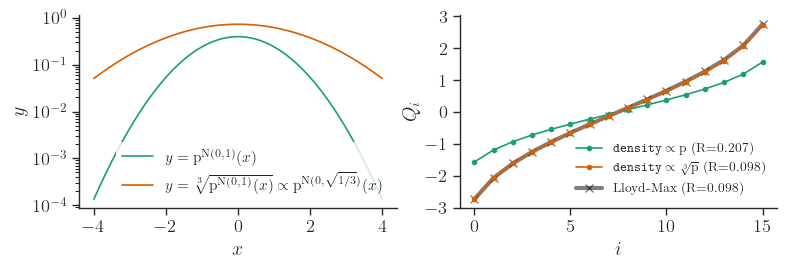

In [ ]:
_, (ax0, ax1) = plt.subplots(ncols=2, figsize=(9, 2.5))

x = torch.linspace(-4, 4, 1001)
ax0.plot(x, scipy.stats.norm.pdf(x), label=r"$y = \mathrm{p}^{\mathrm{N}(0, 1)}(x)$")
ax0.plot(x, scipy.stats.norm.pdf(x)**(1/3), label=r"$y = \sqrt[3]{\mathrm{p}^{\mathrm{N}(0, 1)}(x)} \propto \mathrm{p}^{\mathrm{N}(0, \sqrt{1/3})}(x)$")
ax0.set_yscale("log")
ax0.set_xlabel("$x$")
ax0.set_ylabel(r"$y$")
ax0.legend(loc="lower right")

bits = 4
# n_X, iterations, push = 2**14, 100, False
n_X, iterations, push = 2**20, 200, True

X = sample(n_X, "Normal", seed=1)
for fmt in [
        Q.crd_gauss(bits, multiplier=1),
        Q.crd_gauss(bits),
        Q.lut_lloyd_max(sample(n_X, "Normal", seed=2), bits, iterations=iterations),
    ]:
    name = {
        "CRD-G{1}": r"$\texttt{density} \propto \mathrm{p}$",
        "CRD-G": r"$\texttt{density} \propto \sqrt[3]{\mathrm{p}}$",
        "LM": r"Lloyd-Max",
    }[fmt.name]
    rmse = Q.rmse_norm(X, fmt.quantise(X)).item()
    ax1.plot(fmt.values, label=f"{name} (R={rmse:.3f})",
             **(dict(LM_UNDERLAY_ARGS, c="k") if fmt.name == "LM" else dict(marker="o")))
ax1.set_yticks(list(range(-3, 3+1)))
ax1.set_xlabel("$i$")
ax1.set_ylabel("$Q_i$")
ax1.legend(loc="lower right", fontsize=9.5)

plot_utils.save("normal_crd_example_4bit", push=push)

remote: Updating references: 100% (1/1)           


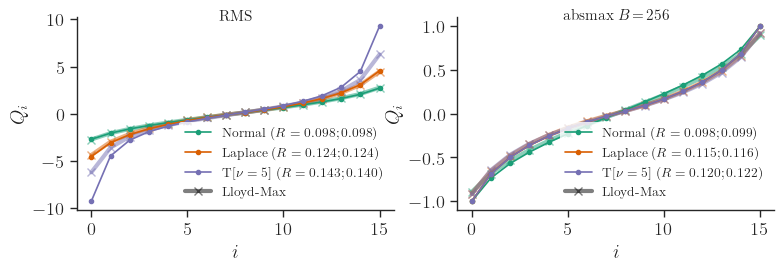

In [4]:
_, (ax0, ax1) = plt.subplots(ncols=2, figsize=(9, 2.5))

bits = 4
# n_X, iterations, push = 2**14, 100, False
n_X, iterations, push = 2**20, 300, True

studentt_dof = 5
block_size = 256
dists = [
    dict(dist="Normal", scale=1.0),
    dict(dist="Laplace", scale=2**-0.5),
    dict(dist="StudentT", dof=studentt_dof, scale=((studentt_dof - 2) / studentt_dof) ** .5),
]
for dist, color in zip(dists, plot_utils.PALETTE):
    torch.manual_seed(1)
    X = sample(n_X, **dist, seed=1)
    X_LM = sample(n_X, **dist, seed=2)
    assert 0.95 <= X.pow(2).mean().sqrt().item() <= 1.05

    lm_fmt = Q.lut_lloyd_max(X_LM, bits, iterations=iterations)
    block_lm_fmt = Q.lut_lloyd_max(
        X_LM.view(-1, block_size).div(X_LM.view(-1, block_size).abs().amax(-1, keepdim=True)).view(-1),
        bits,
        iterations=iterations,
    )
    if dist["dist"] == "Normal":
        name = "Normal"
        crd_fmt = Q.crd_gauss(bits)
        block_crd_fmt = Q.crd_trunc_gauss(bits, block_size, symmetric=True)
    if dist["dist"] == "Laplace":
        name = "Laplace"
        crd_fmt = Q.crd_laplace(bits)
        block_crd_fmt = Q.crd_trunc_laplace(bits, block_size, symmetric=True)
    if dist["dist"] == "StudentT":
        name = f"T[$\\nu={dist['dof']:.0f}$]"
        crd_fmt = Q.crd_t(bits, dist['dof'])
        block_crd_fmt = Q.crd_trunc_laplace(bits, block_size, symmetric=True)  # TODO

    rmse = Q.rmse_norm(X, crd_fmt.quantise(X)).item()
    lm_rmse = Q.rmse_norm(X, lm_fmt.quantise(X)).item()
    ax0.plot(crd_fmt.values, label=f"{name} ($R={rmse:.3f} ; {lm_rmse:.3f}$)", c=color, marker="o")
    ax0.plot(lm_fmt.values, c=color, **LM_UNDERLAY_ARGS)

    scaling_fmt = Q.LinearScalingFormatV2(block_crd_fmt, Q.BFLOAT16, (block_size,), scaling="absmax")
    block_rmse = Q.rmse_norm(X, scaling_fmt.quantise(X)).item()
    lm_scaling_fmt = Q.LinearScalingFormatV2(block_lm_fmt, Q.BFLOAT16, (block_size,), scaling="absmax")
    lm_block_rmse = Q.rmse_norm(X, lm_scaling_fmt.quantise(X)).item()
    ax1.plot(block_crd_fmt.values, label=f"{name} ($R={block_rmse:.3f} ; {lm_block_rmse:.3f}$)", c=color, marker="o")
    ax1.plot(block_lm_fmt.values, c=color, **LM_UNDERLAY_ARGS)

for ax in [ax0, ax1]:
    ax.set_xlabel("$i$")
    ax.set_ylabel("$Q_i$")
    h, _ = ax.get_legend_handles_labels()
    h.append(matplotlib.lines.Line2D([], [], color="k", **LM_UNDERLAY_ARGS, label="Lloyd-Max"))
    ax.legend(handles=h, loc="lower right", fontsize=9.5)

ax0.set_title("RMS", y=1, va="top")
ax1.set_title(f"absmax $B\\!=\\!{block_size}$", y=1, va="top")

plot_utils.save("crd_curves_4bit", push=push)